In [1]:
%load_ext autoreload
%autoreload 2

import os
# os.environ['OMP_NUM_THREADS'] = '12'

# tensor toolbox stuff
import pyttb as ttb
import numpy as np

# add stuff in common
import goated.utils.exo as ex
import goated.utils.scalers as sc
import goated.goals.physics as goals
import goated.rol_interface.models as rolm
from goated.tucker import GotchaObjective

from matplotlib import pyplot as plt
import scipy.linalg as la

In [2]:
# Exodus file name with tensor data

## large
#fname = '/Users/rjmurr/Documents/ascend/combined-cp-tucker-opt/data/1E3_2D_TearingMode.exo'

## medium
#fname = '/Users/rjmurr/Documents/ascend/combined-cp-tucker-opt/data/output_2D_TearingMode_150x75_S_5E4.exo'

## small
fname = '/Users/rjmurr/Documents/ascend/combined-cp-tucker-opt/data/output_2D_TearingMode_64x32_S_1E3.exo'

do_goal_plots = True  # construct goal plots
save_figs = False     # save figures

In [3]:
# Read tensor from exodus file
exo = ex.ExoInfo()
exo.read_sheet(fname)
time = exo.t
num_time = len(time)

# Some global parameters
vars = [0,1,3,4,6,7,9]       # Exclude BZ, R, RHO_UZ, and U
B_var_ind = [0,1]            # variable indices for magnetic field
rho_var_ind = [2]            # variable index for density
mom_var_ind = [4,5]          # variables for momentum goal
T_var_ind = [6]              # variable index for temperature
tot_var_ind = B_var_ind+rho_var_ind+mom_var_ind+T_var_ind
int_var_ind = rho_var_ind+T_var_ind
kin_var_ind = rho_var_ind +mom_var_ind
mom_time_ind = range(1,num_time)    # time steps for momenum goal (exclude first few)
energy_time_ind = range(0,num_time) # time steps for energy goals

# select subset of variables
X = ttb.tensor(exo.tensor_data[:,:,vars,:])
sz = X.shape
var_labels = [exo.var_name[v] for v in vars]
# scale tensor values so that each variable has roughly the same order of magnitude
scaler = sc.StdScaler(X,exo.var_mode)
Xs = scaler.scale_tensor(X)

In [4]:
hosvd_tol = 0.01    # HOSVD tolerance for initial guess
us0 = ttb.hosvd(Xs, hosvd_tol, verbosity=1)
U0 = scaler.unscale_tensor(us0.full())
fit0 = 1-(X-U0).norm()/X.norm()
print(f'Core size : {np.prod(us0.core.shape)}')

Computing HOSVD...

Shape of core: (12, 16, 5, 9)
||X-T||/||X|| =  0.00525939 <= 0.010000 (tol)
Core size : 8640


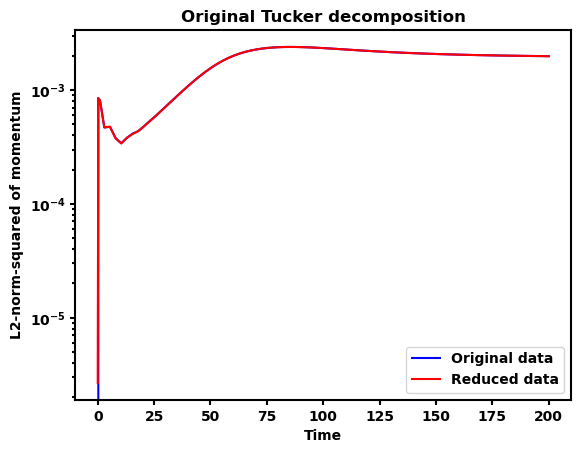

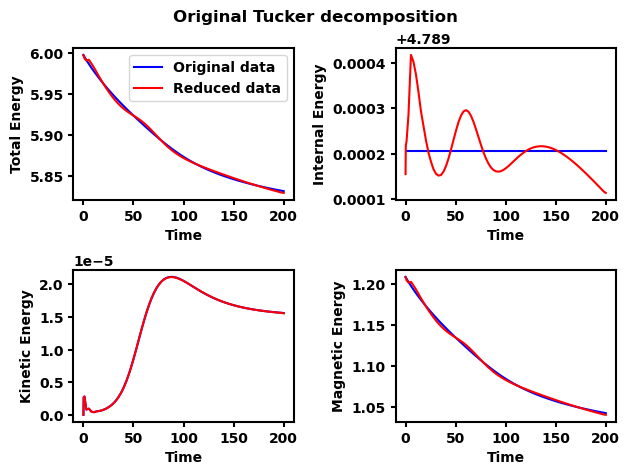

In [5]:
if do_goal_plots:
    fig,ax = goals.plot_momentum(X,us0,mom_var_ind,None,time,exo,scaler)
    ax.set_title('Original Tucker decomposition', fontweight='bold')
    if save_figs:
        fig.savefig('mom-initial.png')

    fig,axs = goals.plot_energies(X,us0,rho_var_ind,T_var_ind,mom_var_ind,B_var_ind,None,time,exo,scaler)
    fig.suptitle('Original Tucker decomposition', fontweight='bold')
    if save_figs:
        fig.savefig('energy-initial.png')

In [6]:
mom_goal = goals.MomentumGoal(X,mom_var_ind,mom_time_ind,exo)
E_goal = goals.TotalEnergyGoal(X,tot_var_ind,energy_time_ind,exo)
T_goal = goals.InternalEnergyGoal(X,int_var_ind,energy_time_ind,exo)
P_goal = goals.KineticEnergyGoal(X,kin_var_ind,energy_time_ind,exo)
B_goal = goals.MagneticEnergyGoal(X,B_var_ind,energy_time_ind,exo)

mom_goal0 = mom_goal.computeValue(U0)
E_goal0 = E_goal.computeValue(U0)
T_goal0 = T_goal.computeValue(U0)
P_goal0 = P_goal.computeValue(U0)
B_goal0 = B_goal.computeValue(U0)

print(f'Initial fit = {fit0:.4f}, momentum goal = {mom_goal0:.2e}, total energy goal = {E_goal0:.2e}, internal energy goal = {T_goal0:.2e}, kinetic energy goal {P_goal0:.2e}, magnetic energy goal = {B_goal0:.2e}')

Initial fit = 0.9999, momentum goal = 2.04e-10, total energy goal = 3.13e-04, internal energy goal = 2.84e-07, kinetic energy goal 3.17e-14, magnetic energy goal = 2.98e-04


In [ ]:
my_goals = [mom_goal,T_goal,P_goal,B_goal]
ng = len(my_goals)+1
weights = [1/(ng*mom_goal0),1/(ng*T_goal0),1/(ng*P_goal0),1/(ng*B_goal0)]
a = 1/(ng*((Xs-us0.full()).norm()**2))
gotcha = GotchaObjective(Xs, scaler, my_goals, weights, a, 1.0, jacobi=True) # gotcha = TuckerObjective(Xs)

precondition = True
rol_params = None  # use defaults inferred for goccha argument.
problem = rolm.GoatedRolModel(gotcha, us0)
problem.solve(precondition=precondition)



Truncated CG Trust-Region Solver
  iter  value          gnorm          snorm          delta          #fval     #grad     tr_flag   iterCG    flagCG    
  0     1.000000e+00   1.428316e+03   ---            1.000000e+01   1         1         ---       ---       ---       
  1     2.361924e-01   3.636562e+01   1.040967e+00   2.500000e+01   2         2         0         31        0         
  2     2.312197e-01   1.882671e+00   9.089405e-02   6.250000e+01   3         3         0         28        0         
  3     2.296732e-01   1.552049e+00   4.956698e-02   1.562500e+02   4         4         0         27        0         
  4     2.290091e-01   5.179097e-01   3.393757e-02   3.906250e+02   5         5         0         26        0         
  5     2.287238e-01   3.021881e-01   2.106614e-02   9.765625e+02   6         6         0         25        0         
  6     2.286014e-01   1.004108e-01   1.448597e-02   2.441406e+03   7         7         0         25        0         
  7     2.2854

In [8]:
us1 = problem.decomp
U1 = scaler.unscale_tensor(us1.full())
fit1 = 1-(X-U1).norm()/X.norm()
mom_goal1 = mom_goal.computeValue(U1)
E_goal1 = E_goal.computeValue(U1)
T_goal1 = T_goal.computeValue(U1)
P_goal1 = P_goal.computeValue(U1)
B_goal1 = B_goal.computeValue(U1)

print(f'Final fit = {fit1:.4f}, momentum goal = {mom_goal1:.2e}, total energy goal = {E_goal1:.2e}, internal energy goal = {T_goal1:.2e}, kinetic energy goal {P_goal1:.2e}, magnetic energy goal = {B_goal1:.2e}')

Final fit = 0.9999, momentum goal = 8.53e-14, total energy goal = 1.16e-06, internal energy goal = 1.52e-08, kinetic energy goal 2.83e-17, magnetic energy goal = 1.44e-06


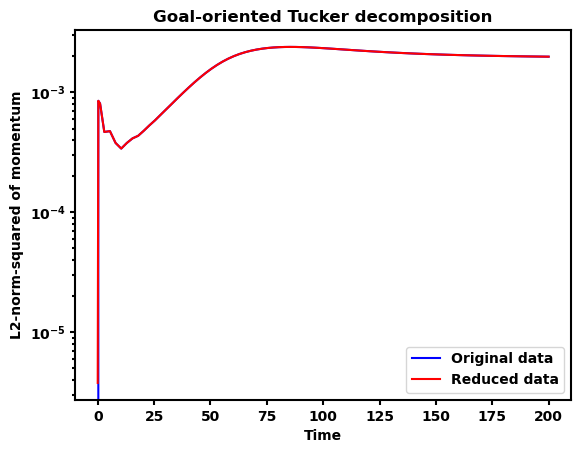

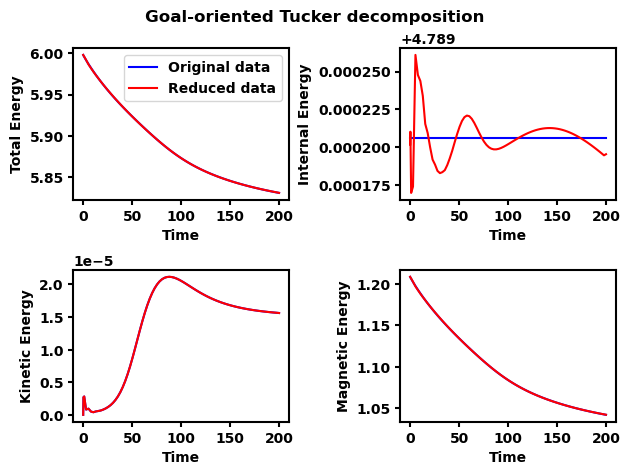

In [9]:
if do_goal_plots:
    fig,ax = goals.plot_momentum(X,us1,mom_var_ind,None,time,exo,scaler)
    ax.set_title('Goal-oriented Tucker decomposition',fontweight='bold')
    if save_figs:
        fig.savefig('mom-final.png')

    fig,axs = goals.plot_energies(X,us1,rho_var_ind,T_var_ind,mom_var_ind,B_var_ind,None,time,exo,scaler)
    fig.suptitle('Goal-oriented Tucker decomposition',fontweight='bold')
    if save_figs:
        fig.savefig('energy-final.png')

In [10]:
for k,v in gotcha.times.items():
    print(f'{k} : {np.sum(v)}')


gradient : 2.7079954147338867
gn_diag_block_goal_updates : 8.146966457366943
recompute_bj_prec, marginal : 2.631765365600586
gn_bd_precvec : 0.9721832275390625
recompute hessian : 2.1232900619506836
gn_hessvec, marginal : 11.851595878601074


[(780, 331), (528, 331), (35, 331), (747, 331), (8640, 331)]


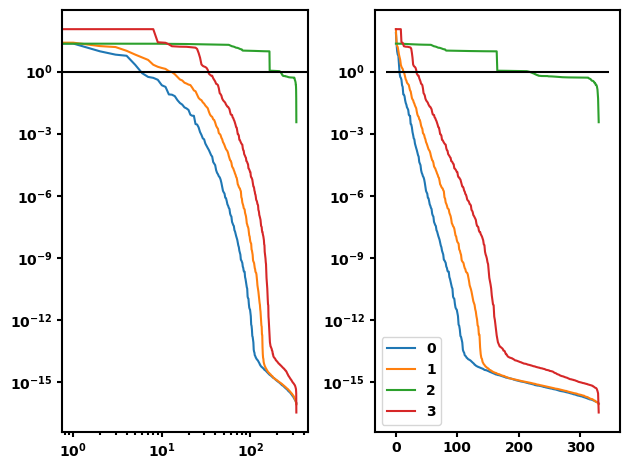

In [11]:

ind = 0
ops0 = gotcha.block_jacobi_ops_cache[ind]
spec_vs = [la.svdvals(op.V) for op in ops0]
fig, axs = plt.subplots(1, 2)
for j, ax in enumerate(axs):
    skipped = []
    handle = ax.loglog if j == 0 else ax.semilogy
    for i, spec in enumerate(spec_vs):
        if spec.size != ops0[i].V.shape[1]:
            continue
        handle(spec)
    xmin, xmax = ax.get_xlim()
    plt.legend(range(len(spec_vs)-len(skipped)))
    ax.hlines(1, xmin, xmax, 'k')
fig.set_tight_layout(True)
fig.show()
print([op.V.shape for op in ops0])

In [12]:
reldiffs = np.zeros((10, 5))
for factor_ind in range(5):
    V0s = [gotcha.block_jacobi_ops_cache[ind][factor_ind].V for ind in range(10)]
    for ind in range(1, 10):
        ma = V0s[ind-1]
        mb = V0s[ind]
        ma = ma.T @ ma
        mb = mb.T @ mb
        val = la.norm(ma - mb, 2) / np.sqrt(la.norm(ma,2)**2 + 1)
        reldiffs[ind, factor_ind] = val
np.set_printoptions(linewidth=200)
print(reldiffs)

[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [8.49614072e-04 6.07056877e-04 1.21571154e-03 6.82068213e-03 2.10904860e-01]
 [4.57513130e-04 3.30493129e-04 2.25634444e-04 2.17970771e-02 2.90482699e-02]
 [8.05727457e-05 3.19325032e-04 6.18242720e-05 6.37463960e-03 7.78493943e-02]
 [2.92478574e-04 8.49952753e-05 6.44043968e-05 1.24586082e-02 1.43580385e-02]
 [5.39519548e-05 1.30385499e-04 2.75866534e-05 3.49172807e-03 3.25333577e-02]
 [1.24646170e-04 3.35129377e-05 2.41462776e-05 5.67488317e-03 7.07495747e-03]
 [2.75144885e-05 5.45019172e-05 1.19133862e-05 1.66718425e-03 1.35915886e-02]
 [5.16247163e-05 1.45706116e-05 9.62430550e-06 2.44563249e-03 3.33267085e-03]
 [1.28396098e-05 2.27485531e-05 5.06882867e-06 7.64018455e-04 5.67552420e-03]]
